# Assignment: Logistic Regression (Loan Approval Prediction)

In [1]:
#Q1. Data Loading & Understanding
#a) Load the dataset into Python.
#b) Display the first 5 rows.
#c) Check the shape of the dataset.
#d) Display the data types of each column.

In [5]:
import pandas as pd

# Load dataset
df = pd.read_csv("C:/Users/abhij/Downloads/loan_approval - loan_approval.csv")   # change filename if needed

# First 5 rows
df.head()

,name,city,income,credit_score,loan_amount,years_employed,points,loan_approved
0,Allison Hill,East Jill,113810,389,39698,27,50,False
1,Brandon Hall,New Jamesside,44592,729,15446,28,55,False
2,Rhonda Smith,Lake Roberto,33278,584,11189,13,45,False
3,Gabrielle Davis,West Melanieview,127196,344,48823,29,50,False
4,Valerie Gray,Mariastad,66048,496,47174,4,25,False


In [4]:
# Shape
df.shape

(2000, 8)

In [3]:
# Data types
df.dtypes

name              object
city              object
income             int64
credit_score       int64
loan_amount        int64
years_employed     int64
points             int64
loan_approved       bool
dtype: object

In [15]:
#Q2. Data Cleaning
#a) Check for missing values in the dataset. 
#b) Handle missing values appropriately. 
#c) Identify categorical columns present in the dataset. 

In [6]:
# Missing values
df.isnull().sum()

name              0
city              0
income            0
credit_score      0
loan_amount       0
years_employed    0
points            0
loan_approved     0
dtype: int64

In [7]:
# Fill missing values
for col in df.columns:
    if df[col].dtype == 'object':
        df[col].fillna(df[col].mode()[0], inplace=True)
    else:
        df[col].fillna(df[col].median(), inplace=True)

C:\Users\abhij\AppData\Local\Temp\ipykernel_22388\1979602085.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mode()[0], inplace=True)
C:\Users\abhij\AppData\Local\Temp\ipykernel_22388\1979602085.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For exam

In [8]:
# Identify categorical columns
cat_cols = df.select_dtypes(include='object').columns
print(cat_cols)

Index(['name', 'city'], dtype='object')


In [9]:
#Q3. Exploratory Data Analysis (EDA)
#a) Plot the distribution of the target variable. 
#b) Analyze the relationship between one numerical feature and the target variable. 
#c) Analyze the relationship between Years of Employment and the target variable.

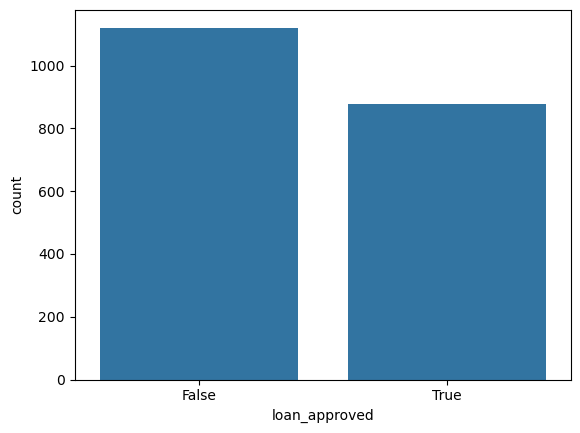

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='loan_approved', data=df)
plt.show()

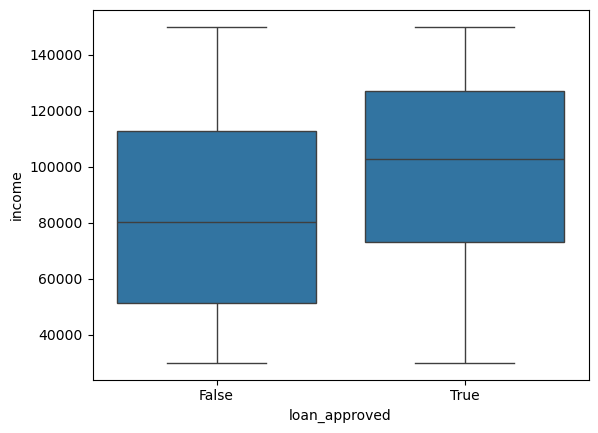

In [12]:
sns.boxplot(x='loan_approved', y='income', data=df)
plt.show()

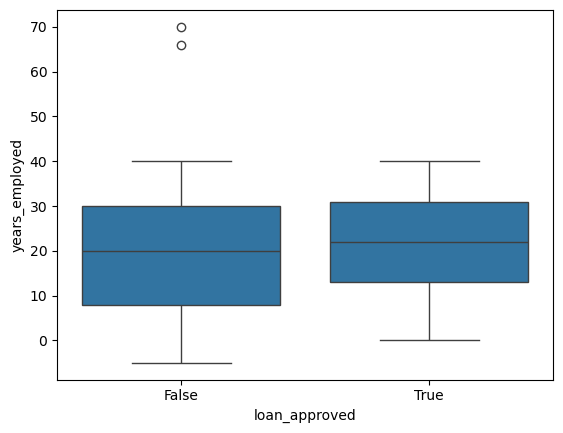

In [13]:
sns.boxplot(x='loan_approved', y='years_employed', data=df)
plt.show()

In [14]:
# Q4. Outlier Detection and Treatment
# a) Detect outliers in numerical columns using the IQR method. 
# b) Treat outliers using capping technique

In [16]:
num_cols = ['income', 'credit_score', 'loan_amount', 'years_employed', 'points']

for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df[col] = df[col].clip(lower, upper)

In [17]:
# Q5. Convert target variables into numerical format suitable for model building and drop unnecessary columns.

In [18]:
# Convert boolean to int
df['loan_approved'] = df['loan_approved'].astype(int)

# Drop unnecessary columns
df.drop(['name'], axis=1, inplace=True)

In [19]:
#Q6. Feature Selection and Data Splitting
#a) Separate independent variables (X) and dependent variable (y).
#b) Split the dataset into training and testing sets.

In [20]:
from sklearn.model_selection import train_test_split

X = df.drop('loan_approved', axis=1)
y = df['loan_approved']

# Convert categorical (city)
X = pd.get_dummies(X, drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [21]:
#Q7. Apply feature scaling to the dataset using StandardScaler.

In [22]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [23]:
#Q8. Logistic Regression Model Building
#a) Train a Logistic Regression model. 
#b) Predict the output for test data.

In [24]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:,1]

In [25]:
#Q9. Model Evaluation – Confusion Matrix
#a) Generate the confusion matrix. 
#b) Interpret the results.

In [26]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
print(cm)

[[207  10]
 [ 24 159]]


#### Interpretation 
##### TP → correctly approved loans
##### TN → correctly rejected loans
##### FP → wrongly approved
##### FN → wrongly rejected